# 1. Import Required Libraries

In this section, we import the necessary libraries for data handling, visualization, and preprocessing.
These libraries will be used for exploratory data analysis (EDA) and data preparation.


In [5]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# 2. Data Loading
In this section, we load the dataset from Google Drive and examine its initial structure.

In [6]:
file_path = "bankruptcy-prevention (1).xlsx"
df = pd.read_excel(file_path)
df.head()

,industrial_risk; management_risk; financial_flexibility; credibility; competitiveness; operating_risk; class
0,0.5;1;0;0;0;0.5;bankruptcy
1,0;1;0;0;0;1;bankruptcy
2,1;0;0;0;0;1;bankruptcy
3,0.5;0;0;0.5;0;1;bankruptcy
4,1;1;0;0;0;1;bankruptcy


In [7]:
df.shape

(250, 1)

# 3. Data Preprocessing

In this section, we clean and structure the dataset for analysis.
This includes splitting columns, assigning proper column names,
and preparing the dataset for EDA.

### Step 1: Split the Single Column

In [8]:
# Split the single column using ';'
df = df.iloc[:,0].str.split(';', expand=True)

df.head()

,0,1,2,3,4,5,6
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


In [9]:
df.shape

(250, 7)

### Step 2: Assign Proper Column Names

In [10]:
df.columns = [
  "industrial_risk",
  "management_risk",
  "financial_flexibility",
  "credibility",
  "competitiveness",
  "operating_risk",
  "class"
]

df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


### Step 3: Check Data Types

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   industrial_risk        250 non-null    object
 1   management_risk        250 non-null    object
 2   financial_flexibility  250 non-null    object
 3   credibility            250 non-null    object
 4   competitiveness        250 non-null    object
 5   operating_risk         250 non-null    object
 6   class                  250 non-null    object
dtypes: object(7)
memory usage: 13.8+ KB


### Step 4: Convert Feature Columns to Numeric

In [12]:
feature_columns = df.columns[:-1]
df[feature_columns] = df[feature_columns].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


### Step 5: Check for Missing Values

In [13]:
df.isnull().sum()

industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

# 4. Exploratory Data Analysis (EDA)
In this section, we analyze the dataset to understand patterns,
distributions, and the class balance.

check class distribution:

In [14]:
df['class'].value_counts()

class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64

In [15]:
df['class'].value_counts(normalize=True) * 100

class
non-bankruptcy    57.2
bankruptcy        42.8
Name: proportion, dtype: float64

### Class Distribution Analysis

The dataset contains:
- 143 non-bankruptcy cases (57.2%)
- 107 bankruptcy cases (42.8%)

The dataset is slightly imbalanced but not severely skewed.
Therefore, model evaluation will focus on recall and precision to ensure
bankruptcy cases are correctly identified.

### 4.1 Class Distribution

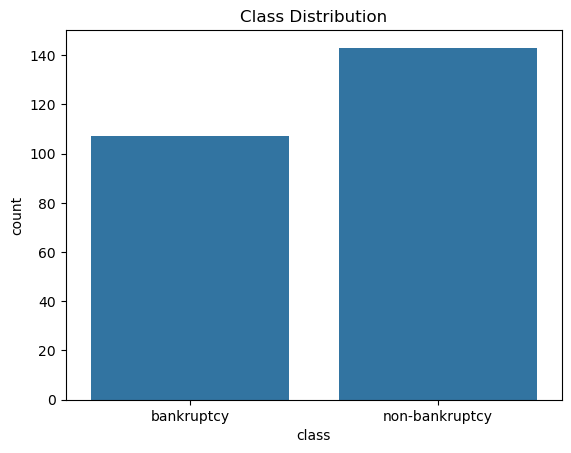

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()

### 4.2 Feature Distribution Analysis
In this section, we analyze the distribution of each risk indicator to understand how risk levels are spread across companies.

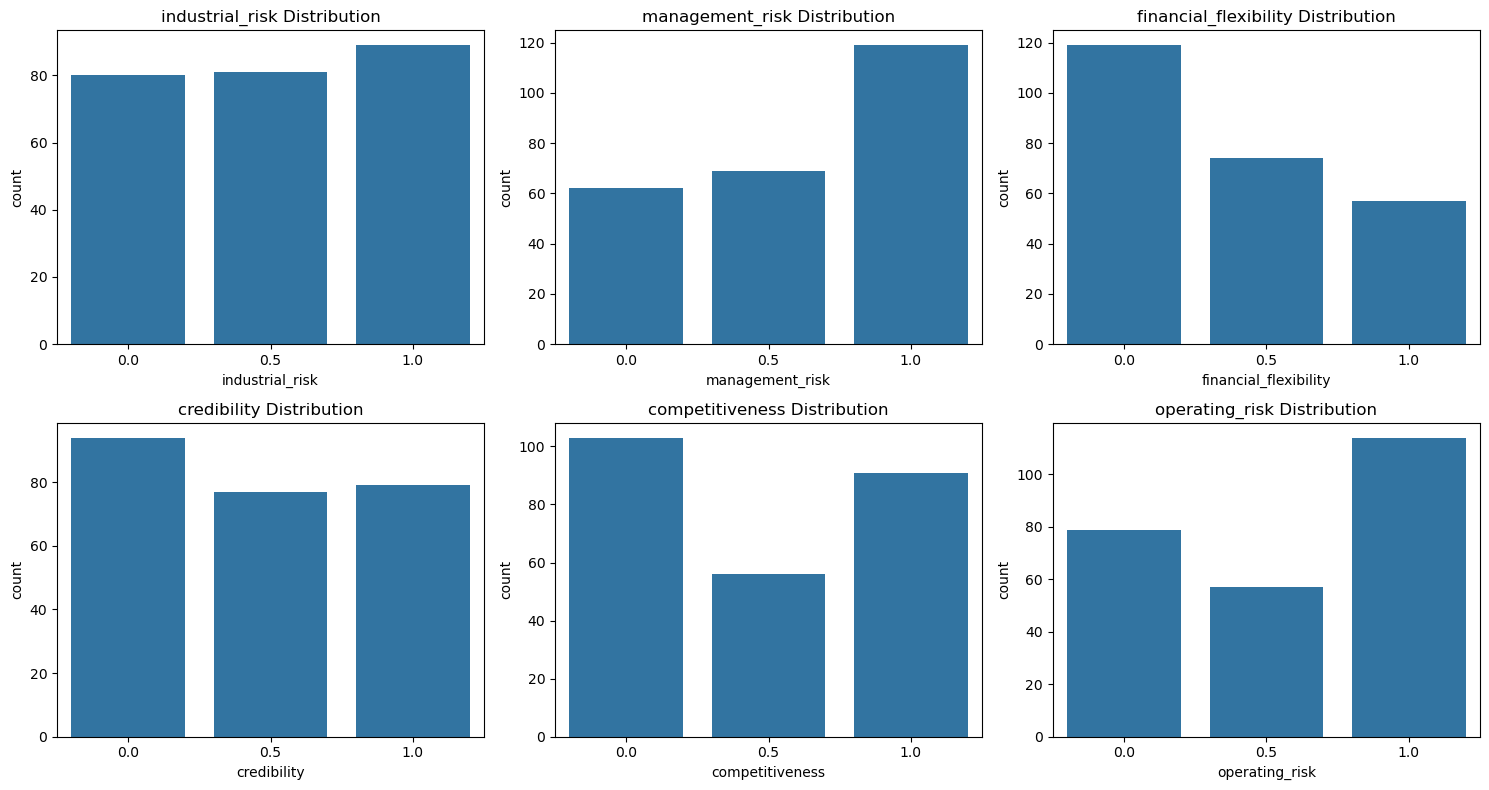

In [17]:
feature_columns = df.columns[:-1]

plt.figure(figsize=(15,8))

for i, col in enumerate(feature_columns):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

### 4.3 Feature vs Target Analysis

In this section, we analyze how each risk indicator relates to bankruptcy.
This helps identify which features may strongly influence the target variable.

#### Plot Feature vs Class

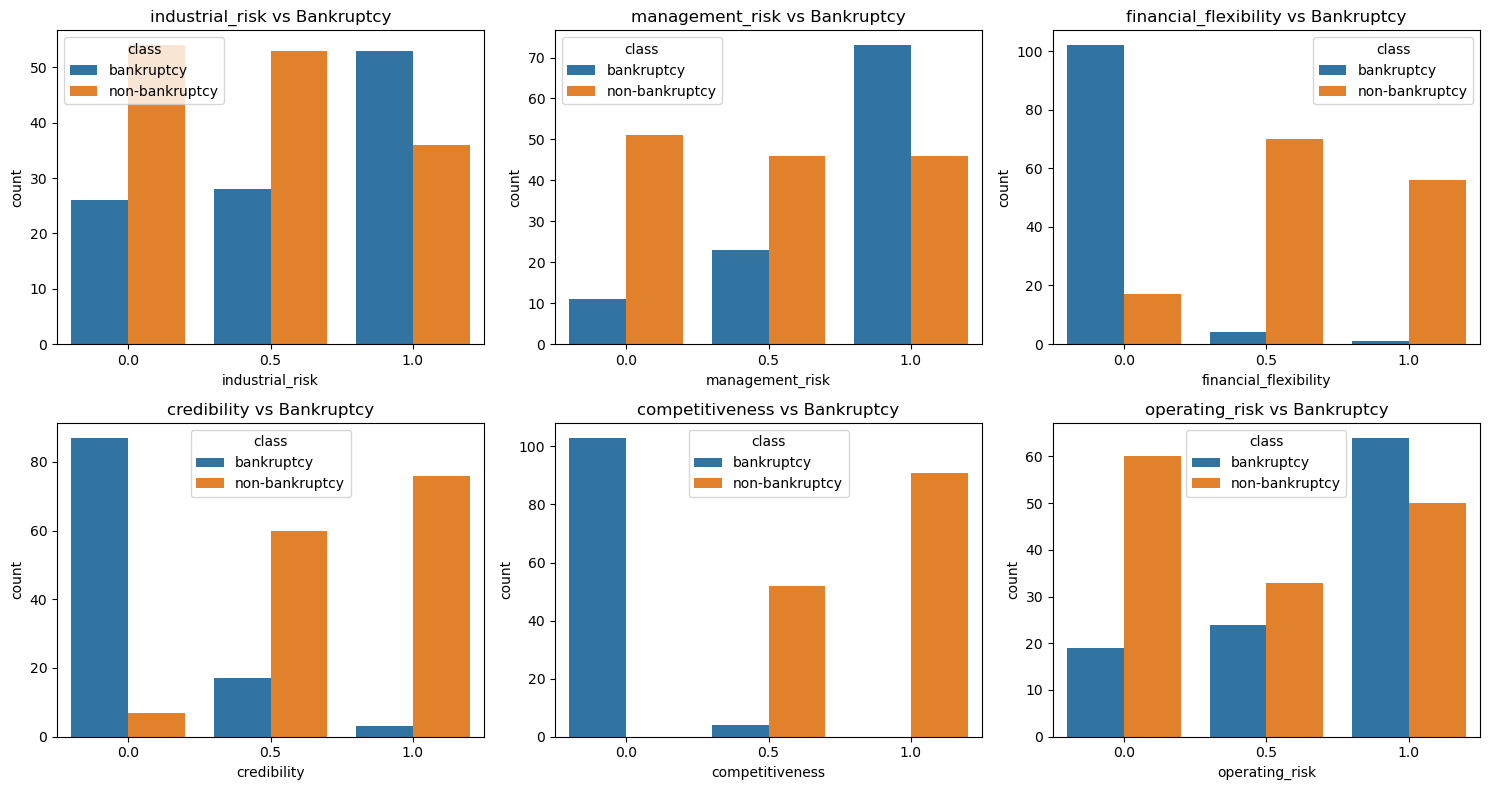

In [18]:
feature_columns = df.columns[:-1]

plt.figure(figsize=(15,8))

for i, col in enumerate(feature_columns):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=col, hue='class', data=df)
    plt.title(f"{col} vs Bankruptcy")

plt.tight_layout()
plt.show()

### Key Observations from Feature vs Target Analysis

- Higher industrial, management, and operating risks are associated with increased bankruptcy.
- Low financial flexibility strongly correlates with bankruptcy.
- Low credibility and low competitiveness are strongly linked to bankruptcy.
- Clear separability is visible between classes across multiple features.

These patterns indicate that the selected risk indicators are meaningful predictors of bankruptcy.

## 4.4 Correlation Analysis

In this section, we analyze the correlation between features to identify relationships and potential multicollinearity.

### Step 1 – Encode Target Temporarily
Before correlation, we must convert class into numeric.

In [19]:
# Create a temporary numeric version of target
df['class_numeric'] = df['class'].map({
    'non-bankruptcy': 0,
    'bankruptcy': 1
})

### Step 2 – Compute Correlation Matrix

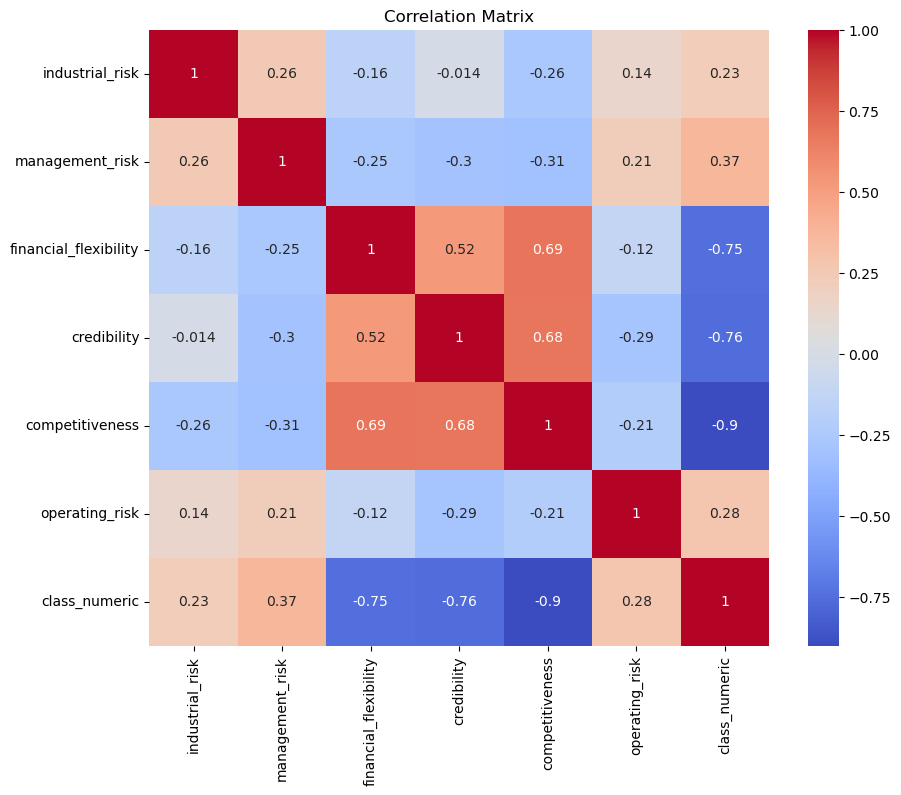

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Correlation Insights

- Competitiveness shows a very strong negative correlation (-0.90) with bankruptcy.
- Credibility (-0.76) and financial flexibility (-0.75) are also strong predictors.
- Management risk and operating risk show moderate positive correlation.
- Some moderate correlation exists between financial flexibility, credibility, and competitiveness, indicating possible multicollinearity.

These results suggest strong predictive signals in the dataset.

### 4.5 Duplicate Check

In this section, we verify whether any duplicate records exist in the dataset.

In [21]:
df.duplicated().sum()

np.int64(147)

In [22]:
df_unique = df.drop_duplicates()
df_unique.shape

(103, 8)

### Duplicate Analysis

The dataset contains 147 duplicate records.

Since this is a classification dataset and duplicates may represent
multiple companies sharing similar risk profiles, we chose to retain them
to preserve the dataset size and avoid losing valuable information.

### 4.6 Statistical Summary

In this section, we analyze the basic statistical properties of the dataset
to validate value ranges and distribution characteristics.

In [23]:
df.describe()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class_numeric
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.518000,0.614000,0.376000,0.470000,0.476000,0.570000,0.428000
std,0.411526,0.410705,0.401583,0.415682,0.440682,0.434575,0.495781
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000
75%,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Statistical Summary Observations

- All feature values are within the expected range (0 to 1).
- No missing or abnormal values are present.
- The mean bankruptcy rate is approximately 42.8%, confirming earlier class distribution analysis.
- Management risk and operating risk show relatively higher average values across companies.

The dataset is clean and ready for modeling.

# Model Building
## Preparing Data for Modeling

In [24]:
# Define features (X) and target (y)

X = df.drop(['class','class_numeric'], axis=1)
y = df['class_numeric']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (250, 6)
Shape of y: (250,)


## Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (200, 6)
X_test: (50, 6)
y_train: (200,)
y_test: (50,)


# Logistic Regression Model

In [26]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Model Predictions

In [27]:
# Predict on test data
y_pred = log_model.predict(X_test)

# See first few predictions
y_pred[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1])



The Logistic Regression model generated predictions for the test dataset based on the learned relationships between the risk indicators and bankruptcy status. The predictions represent whether the model classifies a company as bankrupt (1) or non-bankrupt (0).

### Confusion Matrix

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[29,  0],
       [ 0, 21]])



The confusion matrix shows that the model correctly classified all 50 test observations.
There were no false positives and no false negatives. This means the model successfully identified both bankrupt and non-bankrupt companies without misclassification.

### Classification Report

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50





The classification report shows perfect precision, recall, and F1-score for both classes.
This indicates that the model performed extremely well on the test dataset. The high performance is likely due to strong separability of features such as competitiveness, credibility, and financial flexibility, which were identified during exploratory data analysis.

# Decision Tree Model

In [30]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Model Predictions

In [31]:
y_pred_dt = dt_model.predict(X_test)

y_pred_dt[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1])

### Confusion Matrix

In [32]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_dt)

array([[28,  1],
       [ 0, 21]])

### Classification Report

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.95      1.00      0.98        21

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50





The Decision Tree model achieved an accuracy of 98% on the test dataset.
The model correctly identified all bankrupt companies (recall = 1.00 for class 1),
which is particularly important for bankruptcy prediction tasks. Only one
non-bankrupt company was misclassified as bankrupt. Overall, the model performs
very well, confirming the strong predictive power of the risk indicators.

# Model Comparison

Two models were trained for comparison:

| Model | Accuracy |
|------|------|
| Logistic Regression | 100% |
| Decision Tree | 98% |

Both models performed very well due to strong feature separability in the dataset.
Logistic Regression slightly outperformed the Decision Tree on the test data.

# Feature Importance Analysis

In [34]:
import pandas as pd

# Get feature importance values
feature_importance = pd.Series(dt_model.feature_importances_, index=X.columns)

# Sort them in descending order
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance

competitiveness          0.956138
credibility              0.043862
industrial_risk          0.000000
management_risk          0.000000
financial_flexibility    0.000000
operating_risk           0.000000
dtype: float64

### Feature Importance Insight

Competitiveness is the most important feature for predicting bankruptcy, with credibility having a small influence. This aligns with the earlier EDA where competitiveness showed the strongest relationship with the target.

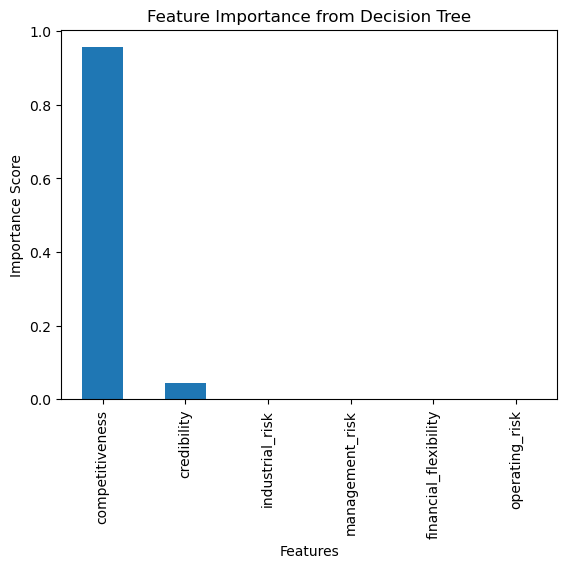

In [35]:
import matplotlib.pyplot as plt

feature_importance.plot(kind='bar')
plt.title("Feature Importance from Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

## Random Forest Model

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Predictions

In [37]:
y_pred_rf = rf_model.predict(X_test)

y_pred_rf[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1])

### Confusion Matrix

In [38]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)

array([[29,  0],
       [ 0, 21]])

### Classification Report

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



Random Forest also performed very well on the dataset.
Since it combines multiple decision trees, it improves model stability and reduces overfitting compared to a single decision tree.

### Random Forest Insight
The Random Forest model achieved perfect classification on the test dataset.
The ensemble of multiple decision trees helps improve prediction stability and confirms that the dataset has strong separability between bankrupt and non-bankrupt companies.

## K-Nearest Neighbors Model

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Model Predictions

In [41]:
y_pred_knn = knn_model.predict(X_test)

y_pred_knn[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1])

### Confusion Matrix

In [42]:
confusion_matrix(y_test, y_pred_knn)

array([[29,  0],
       [ 0, 21]])

### Classification Report

In [43]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



### KNN Model Insight

The K-Nearest Neighbors model achieved an accuracy of 98% on the test dataset.
The model successfully identified all bankrupt companies (recall = 1.00 for class 1),
with only one non-bankrupt company misclassified as bankrupt. This indicates that
the dataset has clear separation between classes, allowing distance-based models
like KNN to perform well.

## Support Vector Machine (SVM) Model

In [44]:
from sklearn.svm import SVC

# Initialize model
svm_model = SVC()

# Train model
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Model Predictions

In [45]:
y_pred_svm = svm_model.predict(X_test)

y_pred_svm[:10]

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1])

### Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_svm)

array([[29,  0],
       [ 0, 21]])

### Classification Report

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        21

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



### SVM Model Insight

The Support Vector Machine model achieved perfect classification on the test dataset. The model successfully separated bankrupt and non-bankrupt companies by identifying an optimal decision boundary. This result further confirms that the dataset contains strong predictive patterns for bankruptcy.

### Model Comparison

| Model | Accuracy |
|------|------|
| Logistic Regression | 100% |
| Decision Tree | 98% |
| Random Forest | 100% |
| K-Nearest Neighbors | 98% |
| Support Vector Machine | 100% |

### Model Comparison Insight

All models performed very well on the dataset due to strong feature separability. Logistic Regression, Random Forest, and SVM achieved perfect accuracy, while Decision Tree and KNN achieved slightly lower accuracy. Overall, Logistic Regression provides a simple and effective baseline model for bankruptcy prediction.

### Model Accuracy Comparison

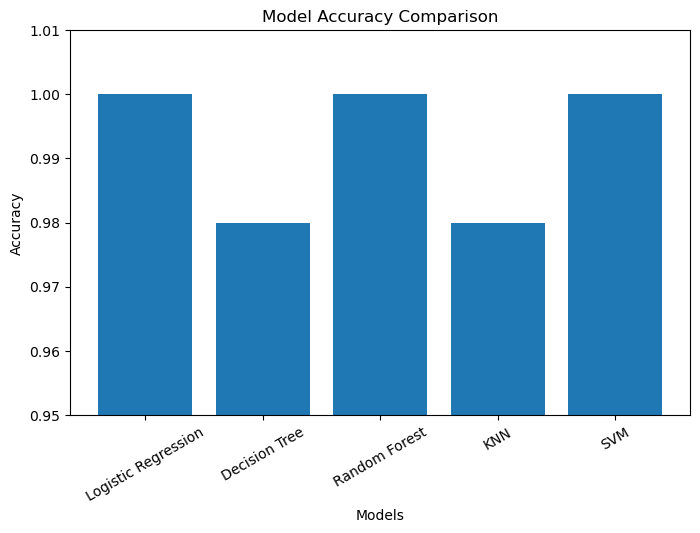

In [48]:
import matplotlib.pyplot as plt

# Model names
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM']

# Accuracy values
accuracy = [1.00, 0.98, 1.00, 0.98, 1.00]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.95,1.01)

plt.xticks(rotation=30)

plt.show()

In [51]:
import pickle

# save trained model
pickle.dump(log_model, open("model.pkl", "wb"))

# save feature columns
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))